# Decision tree for regression

[Master Tree Ensemble Models course](https://www.trainindata.com/p/master-tree-ensemble-models)

In this notebook, we train a decision tree to predict the rent price of an apartment, and then we tune the hyperparameters that control the growth of the tree with a random search.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import loguniform, randint, uniform
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.tree import DecisionTreeRegressor

### Load data

We use the apartment rent data that we prepared in the notebook of the folder prepare-data.

In [2]:
df = pd.read_csv("../prepare-data/apartment_rent.csv", index_col="time")
df.head()

,category,bathrooms,bedrooms,fee,has_photo,pets_allowed,price,square_feet,cityname,state,...,amenity_Patio/Deck,amenity_Playground,amenity_Pool,amenity_Refrigerator,amenity_Storage,amenity_TV,amenity_Tennis,amenity_View,amenity_Washer Dryer,amenity_Wood Floors
time,,,,,,,,,,,,,,,,,,,,,
2018-12-07 09:20:18,housing/rent/apartment,1.0,1.0,No,Thumbnail,Not specified,1191.0,800.0,Atlanta,GA,...,0,0,0,0,0,1,0,0,0,0
2018-12-07 09:20:32,housing/rent/apartment,2.0,4.0,No,Yes,Not specified,1450.0,1880.0,Orange Park,FL,...,0,0,0,0,0,0,0,0,0,0
2018-12-07 09:20:44,housing/rent/apartment,2.0,3.0,No,Yes,Not specified,1395.0,1661.0,Orange Park,FL,...,0,0,0,0,0,0,0,0,0,0
2018-12-07 09:20:55,housing/rent/apartment,2.0,3.0,No,Yes,Not specified,1255.0,1400.0,Orange Park,FL,...,0,0,0,0,0,0,1,0,0,0
2018-12-07 09:20:58,housing/rent/apartment,2.0,2.0,No,Yes,Not specified,1693.0,1346.0,Atlanta,GA,...,0,0,0,0,0,1,0,0,0,0


In [3]:
# the percentage of missing data in the variables that show missing values
missing = df.isna().mean().mul(100)
missing[missing > 0].round(2)

bathrooms    0.06
bedrooms     0.12
cityname     0.30
state        0.30
latitude     0.03
longitude    0.03
dtype: float64

In [4]:
# the trees from Scikit-learn take numbers, so we replace the categories by integers
categorical_vars = df.select_dtypes("str").columns
df[categorical_vars] = df[categorical_vars].apply(lambda var: var.astype("category").cat.codes)

df.head()

,category,bathrooms,bedrooms,fee,has_photo,pets_allowed,price,square_feet,cityname,state,...,amenity_Patio/Deck,amenity_Playground,amenity_Pool,amenity_Refrigerator,amenity_Storage,amenity_TV,amenity_Tennis,amenity_View,amenity_Washer Dryer,amenity_Wood Floors
time,,,,,,,,,,,,,,,,,,,,,
2018-12-07 09:20:18,1,1.0,1.0,0,1,0,1191.0,800.0,101,10,...,0,0,0,0,0,1,0,0,0,0
2018-12-07 09:20:32,1,2.0,4.0,0,2,0,1450.0,1880.0,1955,9,...,0,0,0,0,0,0,0,0,0,0
2018-12-07 09:20:44,1,2.0,3.0,0,2,0,1395.0,1661.0,1955,9,...,0,0,0,0,0,0,0,0,0,0
2018-12-07 09:20:55,1,2.0,3.0,0,2,0,1255.0,1400.0,1955,9,...,0,0,0,0,0,0,1,0,0,0
2018-12-07 09:20:58,1,2.0,2.0,0,2,0,1693.0,1346.0,101,10,...,0,0,0,0,0,1,0,0,0,0


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns="price"),
    df["price"],
    test_size=0.3,
    random_state=0,
)

X_train.shape, X_test.shape

((69872, 39), (29946, 39))

### Set up the model

We show the hyperparameters with their default values, so that we can see the effect of changing them later on.

In [6]:
tree = DecisionTreeRegressor(
    # how the tree looks for the best split
    criterion="squared_error",
    splitter="best",
    max_features=None,

    # how far the tree grows
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,

    # pruning and reproducibility
    ccp_alpha=0.0,
    random_state=0,
)

tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes m

### Evaluate the model

We look at the root mean squared error and at the r squared in the train and test sets to find out if the tree overfits.

In [7]:
def evaluate(model, X_train, y_train, X_test, y_test):
    for name, X, y in [("train", X_train, y_train), ("test", X_test, y_test)]:
        rmse = root_mean_squared_error(y, model.predict(X))
        r2 = r2_score(y, model.predict(X))
        print(f"{name} rmse: {rmse:.2f}, r2: {r2:.4f}")


evaluate(tree, X_train, y_train, X_test, y_test)

train rmse: 27.76, r2: 0.9991
test rmse: 528.12, r2: 0.6311


### Search for better hyperparameters

The tree that we trained so far grows until the leaves contain one apartment, and that is why it overfits. Now we sample values for the hyperparameters that control the growth of the tree from continuous and discrete distributions, and we evaluate each combination with cross validation.

In [8]:
param_distributions = {
    "max_depth": randint(5, 40),
    "min_samples_split": randint(2, 200),
    "min_samples_leaf": randint(1, 100),
    "min_impurity_decrease": loguniform(1e-6, 1e-2),
    # "ccp_alpha": loguniform(1e-6, 1e-1),
}

search = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=0),
    param_distributions,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=0,
)

search.fit(X_train, y_train)

search.best_params_

{'max_depth': 19,
 'min_impurity_decrease': np.float64(0.00026997445607557957),
 'min_samples_leaf': 13,
 'min_samples_split': 123}

In [9]:
# the standard deviation tells us how much the metric changes across the folds
results = pd.DataFrame(search.cv_results_)
results = results.sort_values("rank_test_score")

results[["mean_test_score", "std_test_score", "rank_test_score"]].head(10)

,mean_test_score,std_test_score,rank_test_score
16,-548.509831,64.212928,1
2,-558.344191,58.380823,2
17,-562.442349,55.059065,3
11,-567.174448,60.457570,4
4,-574.256186,54.066182,5
9,-581.756857,61.184468,6
12,-584.459833,57.098686,7
10,-589.782833,60.937963,8
1,-590.517024,60.031356,9
7,-592.612079,53.335450,10


In [10]:
best = results.iloc[0]

print(f"best cross validation rmse: {-best['mean_test_score']:.2f} +/- {best['std_test_score']:.2f}")

best cross validation rmse: 548.51 +/- 64.21


### Evaluate the new model

We compare the performance of the tuned tree with the performance of the tree that we trained with the default hyperparameters.

In [11]:
evaluate(search.best_estimator_, X_train, y_train, X_test, y_test)

train rmse: 493.54, r2: 0.7109
test rmse: 481.20, r2: 0.6938


### The predictions of a tree

A decision tree returns the same value for every apartment that falls in the same leaf, so the number of different predictions that it can make is the number of leaves of the tree.

In [12]:
predictions = search.best_estimator_.predict(X_test)

print(f"leaves: {search.best_estimator_.get_n_leaves()}")
print(f"different predictions: {len(pd.unique(predictions))}")

leaves: 1040
different predictions: 1040


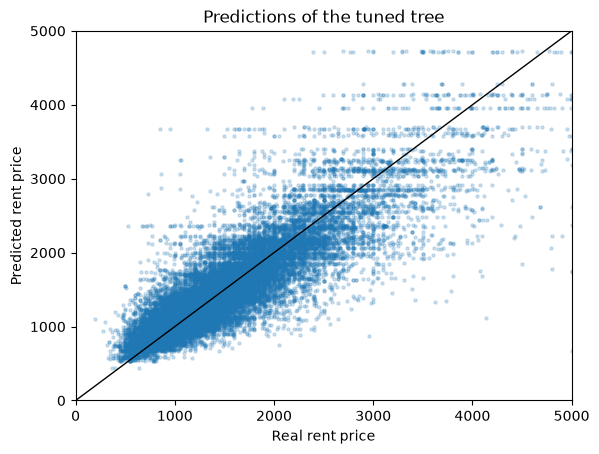

In [13]:
# we zoom into the most common prices, because a few apartments cost more than 30000
plt.scatter(y_test, predictions, alpha=0.2, s=5)
plt.plot([0, 5000], [0, 5000], color="black", linewidth=1)
plt.xlim(0, 5000)
plt.ylim(0, 5000)
plt.xlabel("Real rent price")
plt.ylabel("Predicted rent price")
plt.title("Predictions of the tuned tree")
plt.show()

This tree has so many leaves that the predictions look continuous. 


To see that the output of a tree is in fact a series of steps, we train a very small tree, with a depth of three, which can only return eight different values.

In [14]:
small_tree = DecisionTreeRegressor(max_depth=3, random_state=0)
small_tree.fit(X_train, y_train)

small_predictions = small_tree.predict(X_test)
len(pd.unique(small_predictions))

8

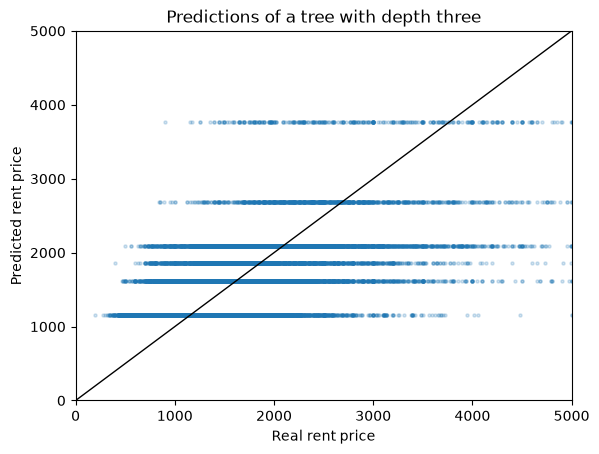

In [15]:
plt.scatter(y_test, small_predictions, alpha=0.2, s=5)
plt.plot([0, 5000], [0, 5000], color="black", linewidth=1)
plt.xlim(0, 5000)
plt.ylim(0, 5000)
plt.xlabel("Real rent price")
plt.ylabel("Predicted rent price")
plt.title("Predictions of a tree with depth three")
plt.show()

### Monotonic constraint

A bigger apartment should not be cheaper than a smaller one when everything else stays the same, yet a tree that grows deep predicts exactly that in the regions where it saw few apartments. With a monotonic constraint we tell the tree that the prediction can only increase with the square feet, where 1 means increasing, -1 means decreasing and 0 leaves the variable free.

In [16]:
monotonic_cst = [1 if var == "square_feet" else 0 for var in X_train.columns]

deep_tree = DecisionTreeRegressor(max_depth=25, random_state=0)
deep_tree.fit(X_train, y_train)

constrained_tree = DecisionTreeRegressor(max_depth=25, monotonic_cst=monotonic_cst, random_state=0)
constrained_tree.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",25
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"monotonic_cst monotonic_cst: array-like of int of shape (n_features), default=NoneIndicates the monotonicity constraint to enforce on each feature. - 1: monotonic increase - 0: no constraint - -1: monotonic decreaseIf monotonic_cst is None, no constraints are applied.Monotonicity constraints are not supported for: - multioutput regressions (i.e. when `n_outputs_ > 1`).Read more in the :ref:`User Guide <monotonic_cst_gbdt>`... versionadded:: 1.4","[0, 0, ...]"
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_fea

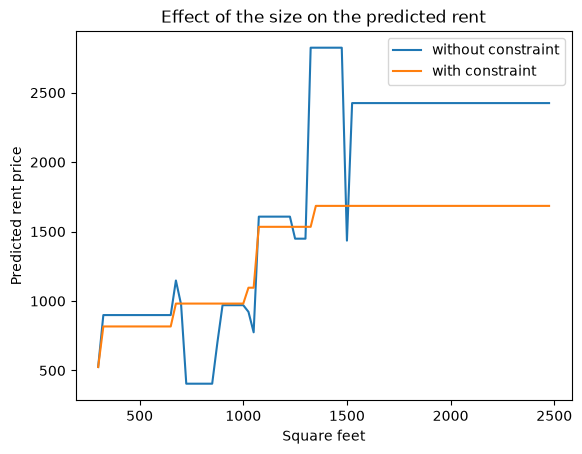

In [17]:
# we take one apartment and change only its size
apartment = X_test.iloc[[0]]
sizes = range(300, 2500, 25)
grid = pd.concat([apartment.assign(square_feet=size) for size in sizes])

plt.plot(sizes, deep_tree.predict(grid), label="without constraint")
plt.plot(sizes, constrained_tree.predict(grid), label="with constraint")
plt.xlabel("Square feet")
plt.ylabel("Predicted rent price")
plt.title("Effect of the size on the predicted rent")
plt.legend()
plt.show()